# Chapter 53 — Limits of Fixed-Window MLP Models

## Learning goals

Chapter 52 trained an MLP language model on random batches and evaluated it on a held-out text slice.

Before changing the training target layout, this chapter examines what the model architecture can and cannot represent efficiently.

By the end of this chapter, you should be able to:

- Explain the hard visibility cutoff created by a fixed context window.
- Explain how flattening preserves position-specific slots but removes the sequence axis.
- Show why one trained MLP accepts only its configured context length.
- Derive and verify the model's parameter-count formula.
- Plot parameter count as context length changes.
- Explain why more visible tokens do not guarantee better predictions.
- Describe the difference between fixed slot weights and content-dependent position mixing.
- Explain why these limits motivate attention without claiming that attention removes every context limit.

## The big idea

The fixed-window MLP follows one simple path:

```text
fixed number of token IDs
→ token embeddings
→ one flattened vector
→ hidden layer
→ next-token logits
```

Its simplicity provides a useful baseline, but it creates four linked constraints:

- Tokens before the window are invisible.
- The flattened vector has one architecture-specific width.
- The first linear layer grows when the context length grows.
- Position mixing uses fixed learned slot connections rather than an explicit input-dependent lookup between positions.

A larger window provides more input only when the architecture and training data can make useful predictions from it.

## Terms used in this chapter

- A **fixed-window model** accepts a configured number of previous tokens.
- **Context length** is the number of token positions in that window.
- A **hard cutoff** is the boundary before which tokens are absent from the model input.
- **Flattening** concatenates the embedding slots into one vector.
- A **position-specific slot** is the fixed segment of that vector assigned to one context position.
- **Parameter count** is the number of trainable scalar values in a model.
- **Content-dependent mixing** combines positions using coefficients computed from the current input.
- **Attention** is a later mechanism that computes content-dependent relationships between sequence positions.

## A fixed window creates a hard cutoff

When predicting the final character of a string, a context window contains only the chosen number of immediately preceding characters.

Print several suffixes to make the cutoff visible.

In [1]:
text = "alice went to the store because alice wanted milk"

print("complete preceding text:", repr(text[:-1]))
print("target character:", repr(text[-1]))
print()
print("context length | visible context")
print("-" * 57)
for context_length in [4, 8, 16, 32]:
    visible_context = text[:-1][-context_length:]
    print(f"{context_length:>14} | {visible_context!r}")

complete preceding text: 'alice went to the store because alice wanted mil'
target character: 'k'

context length | visible context
---------------------------------------------------------
             4 | ' mil'
             8 | 'nted mil'
            16 | 'alice wanted mil'
            32 | 'e store because alice wanted mil'


A length-four model sees only `' mil'` before predicting `'k'`.

Information before that suffix is not compressed or ignored by choice because it never enters the model.

A longer window moves the cutoff earlier, but every finite window still has a cutoff.

## Recreate the fixed-window MLP

Use the validated Chapter 50 model definition so its input checks expose the configured-width contract.

The first linear layer receives `context_length × embedding_dimension` features.

In [2]:
from typing import cast

import torch

device = "cpu"


class MlpLanguageModel(torch.nn.Module):
    def __init__(
        self,
        vocabulary_size: int,
        context_length: int,
        embedding_dimension: int,
        hidden_size: int,
    ) -> None:
        super().__init__()

        self.context_length: int = context_length
        self.embedding_dimension: int = embedding_dimension
        self.token_embedding_table: torch.nn.Embedding = torch.nn.Embedding(
            vocabulary_size,
            embedding_dimension,
        )
        self.first_linear_layer: torch.nn.Linear = torch.nn.Linear(
            context_length * embedding_dimension,
            hidden_size,
        )
        self.nonlinearity: torch.nn.Tanh = torch.nn.Tanh()
        self.output_layer: torch.nn.Linear = torch.nn.Linear(
            hidden_size,
            vocabulary_size,
        )

    def forward(self, input_token_ids: torch.Tensor) -> torch.Tensor:
        if input_token_ids.ndim != 2:
            raise ValueError(
                "input_token_ids must have shape [batch size, context length]."
            )
        if input_token_ids.shape[1] != self.context_length:
            raise ValueError(
                f"Expected context length {self.context_length}, "
                f"received {input_token_ids.shape[1]}."
            )

        token_embeddings = self.token_embedding_table(input_token_ids)
        flattened_embeddings = token_embeddings.reshape(
            input_token_ids.shape[0],
            self.context_length * self.embedding_dimension,
        )
        hidden_values = self.first_linear_layer(flattened_embeddings)
        activated_hidden_values = self.nonlinearity(hidden_values)
        return cast(torch.Tensor, self.output_layer(activated_hidden_values))


print("device:", device)

device: cpu


## Flattening uses rigid position slots

A small deterministic tensor shows exactly how four position vectors become one feature vector.

In [3]:
fake_embeddings = torch.tensor(
    [
        [
            [1.0, 2.0, 3.0],
            [4.0, 5.0, 6.0],
            [7.0, 8.0, 9.0],
            [10.0, 11.0, 12.0],
        ]
    ],
    device=device,
)
flattened_embeddings = fake_embeddings.reshape(1, 4 * 3)

print("embedding shape:", fake_embeddings.shape)
print(fake_embeddings)
print()
print("flattened shape:", flattened_embeddings.shape)
print(flattened_embeddings)

embedding shape: torch.Size([1, 4, 3])
tensor([[[ 1.,  2.,  3.],
         [ 4.,  5.,  6.],
         [ 7.,  8.,  9.],
         [10., 11., 12.]]])

flattened shape: torch.Size([1, 12])
tensor([[ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.]])


Flattening does not erase order because features `0:3`, `3:6`, `6:9`, and `9:12` still identify four different slots.

It does remove the separate sequence dimension, so later layers receive one record with a fixed layout rather than a list of position vectors.

Moving a token to another position moves its embedding values to a different feature segment and therefore changes which first-layer weights process them.

## One model instance accepts one context length

Build a length-four model, run a valid input, and show the clear error produced by a length-eight input.

In [4]:
torch.manual_seed(53)
length_four_model = MlpLanguageModel(
    vocabulary_size=20,
    context_length=4,
    embedding_dimension=8,
    hidden_size=16,
).to(device)
valid_input_ids = torch.zeros((2, 4), dtype=torch.long, device=device)
valid_logits = length_four_model(valid_input_ids)

print("valid input shape:", valid_input_ids.shape)
print("valid output shape:", valid_logits.shape)

invalid_input_ids = torch.zeros((2, 8), dtype=torch.long, device=device)
try:
    length_four_model(invalid_input_ids)
except ValueError as error:
    print("length-eight input error:", error)

valid input shape: torch.Size([2, 4])
valid output shape: torch.Size([2, 20])
length-eight input error: Expected context length 4, received 8.


A model built for four positions cannot accept eight positions without replacing its first linear layer.

Replacing that layer changes trainable parameters, so extending the window is an architecture change rather than a runtime setting for this MLP.

## Derive the parameter-count formula

Let `V` be vocabulary size, `C` context length, `D` embedding dimension, and `H` hidden size.

The model contains:

- `V × D` token-embedding parameters.
- `H × (C × D) + H` first-linear-layer parameters.
- `V × H + V` output-layer parameters.

Only the first linear layer depends on `C` in this architecture.

Each additional context position adds exactly `D × H` first-layer weights.

## Compute counts without constructing models

Implement the formula once and return the contribution from each trainable component.

In [5]:
def count_mlp_language_model_parameters(
    vocabulary_size: int,
    context_length: int,
    embedding_dimension: int,
    hidden_size: int,
) -> dict[str, int]:
    if (
        min(
            vocabulary_size,
            context_length,
            embedding_dimension,
            hidden_size,
        )
        < 1
    ):
        raise ValueError("Every model dimension must be at least 1.")

    embedding_parameters = vocabulary_size * embedding_dimension
    first_linear_parameters = (
        hidden_size * context_length * embedding_dimension + hidden_size
    )
    output_layer_parameters = vocabulary_size * hidden_size + vocabulary_size
    total_parameters = (
        embedding_parameters + first_linear_parameters + output_layer_parameters
    )

    return {
        "embedding_parameters": embedding_parameters,
        "first_linear_parameters": first_linear_parameters,
        "output_layer_parameters": output_layer_parameters,
        "total_parameters": total_parameters,
    }

Use fixed values `V=50`, `D=64`, and `H=256` to isolate the effect of context lengths 8, 32, and 128.

In [6]:
vocabulary_size = 50
embedding_dimension = 64
hidden_size = 256
context_lengths = [8, 32, 128]

print("context | flattened | embedding | first linear | output | total")
print("-" * 72)
for context_length in context_lengths:
    counts = count_mlp_language_model_parameters(
        vocabulary_size=vocabulary_size,
        context_length=context_length,
        embedding_dimension=embedding_dimension,
        hidden_size=hidden_size,
    )
    flattened_size = context_length * embedding_dimension
    print(
        f"{context_length:>7} | "
        f"{flattened_size:>9} | "
        f"{counts['embedding_parameters']:>9} | "
        f"{counts['first_linear_parameters']:>12} | "
        f"{counts['output_layer_parameters']:>6} | "
        f"{counts['total_parameters']:>7}"
    )

context | flattened | embedding | first linear | output | total
------------------------------------------------------------------------
      8 |       512 |      3200 |       131328 |  12850 |  147378
     32 |      2048 |      3200 |       524544 |  12850 |  540594
    128 |      8192 |      3200 |      2097408 |  12850 | 2113458


The embedding and output counts remain constant because `V`, `D`, and `H` remain constant.

The flattened width and first-layer count each quadruple approximately when context length quadruples.

The bias contributes the same additional 256 parameters at every context length.

## Verify the formula with PyTorch

Instantiate the three models and compare the formula with the parameter tensors PyTorch creates.

In [7]:
def count_parameters_in_model(model: torch.nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters())


torch.manual_seed(53)
print("context | formula count | PyTorch count | match")
print("-" * 54)
for context_length in context_lengths:
    model = MlpLanguageModel(
        vocabulary_size=vocabulary_size,
        context_length=context_length,
        embedding_dimension=embedding_dimension,
        hidden_size=hidden_size,
    ).to(device)
    formula_count = count_mlp_language_model_parameters(
        vocabulary_size=vocabulary_size,
        context_length=context_length,
        embedding_dimension=embedding_dimension,
        hidden_size=hidden_size,
    )["total_parameters"]
    pytorch_count = count_parameters_in_model(model)
    print(
        f"{context_length:>7} | "
        f"{formula_count:>13} | "
        f"{pytorch_count:>13} | "
        f"{formula_count == pytorch_count}"
    )

context | formula count | PyTorch count | match
------------------------------------------------------
      8 |        147378 |        147378 | True
     32 |        540594 |        540594 | True
    128 |       2113458 |       2113458 | True


Every formula result matches the corresponding PyTorch model, confirming that the growth is part of the architecture.

## Measure the cost of each added position

For `D=64` and `H=256`, every extra context position adds `64 × 256 = 16,384` weights.

Check that constant increment directly.

In [8]:
parameters_added_per_position = embedding_dimension * hidden_size
length_eight_count = count_mlp_language_model_parameters(
    vocabulary_size,
    context_length=8,
    embedding_dimension=embedding_dimension,
    hidden_size=hidden_size,
)["total_parameters"]
length_nine_count = count_mlp_language_model_parameters(
    vocabulary_size,
    context_length=9,
    embedding_dimension=embedding_dimension,
    hidden_size=hidden_size,
)["total_parameters"]

print("formula increment:", parameters_added_per_position)
print("observed increment:", length_nine_count - length_eight_count)

formula increment: 16384
observed increment: 16384


The equal increments show that first-layer and total parameter counts grow linearly with context length when the other dimensions stay fixed.

## Plot parameter growth

Plot total parameters and first-layer parameters across a wider range of context lengths.

The vertical gap remains constant because the embedding table and output layer do not change.

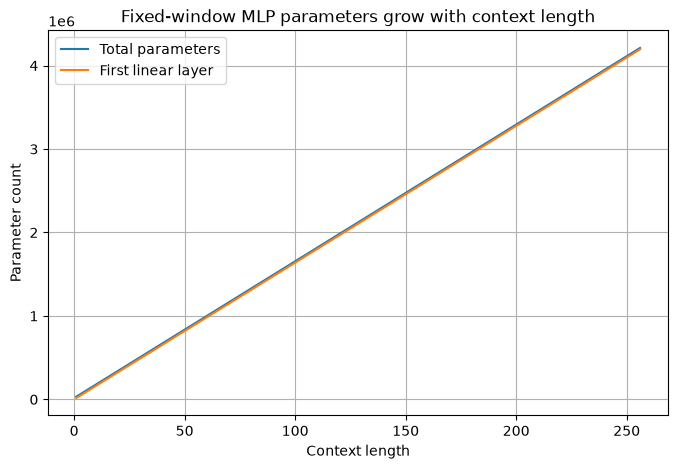

In [9]:
import matplotlib.pyplot as plt

context_lengths_for_plot = list(range(1, 257))
total_parameter_counts: list[int] = []
first_linear_parameter_counts: list[int] = []

for context_length in context_lengths_for_plot:
    counts = count_mlp_language_model_parameters(
        vocabulary_size=vocabulary_size,
        context_length=context_length,
        embedding_dimension=embedding_dimension,
        hidden_size=hidden_size,
    )
    total_parameter_counts.append(counts["total_parameters"])
    first_linear_parameter_counts.append(counts["first_linear_parameters"])

plt.figure(figsize=(8, 5))
plt.plot(
    context_lengths_for_plot,
    total_parameter_counts,
    label="Total parameters",
)
plt.plot(
    context_lengths_for_plot,
    first_linear_parameter_counts,
    label="First linear layer",
)
plt.xlabel("Context length")
plt.ylabel("Parameter count")
plt.title("Fixed-window MLP parameters grow with context length")
plt.grid(True)
plt.legend()
plt.show()

Both lines are straight because each additional position adds the same number of weights.

This linear parameter growth is not the only training cost, but it is the cost caused directly by flattening into the first layer.

## Fixed slot weights are not attention

Split the first-layer weight matrix into one block per context position:

```text
W = [W₀ W₁ W₂ ... W꜀₋₁]
```

Before the nonlinearity, the layer combines embeddings as `W₀e₀ + W₁e₁ + ... + b`.

Each position has its own learned block, but those blocks are the same for every example after training.

The later nonlinearity allows the MLP to learn useful content-dependent functions, so the model is not limited to a simple constant average.

What it lacks is an explicit operation that compares current token content across positions and computes new mixing coefficients for this particular input.

## Why a larger window may not help

Increasing context length can expose an earlier useful clue, but it also changes the learning problem.

A larger fixed-window MLP has:

- More first-layer parameters to estimate.
- More computation in the first linear layer.
- More opportunities to fit irrelevant correlations.
- The same absence of an explicit content-dependent position-mixing step.

Useful long context therefore depends on suitable data, optimization, and architecture rather than context length alone.

## Why these limits motivate attention

Attention keeps a sequence axis while positions exchange information.

Its mixing coefficients are computed from the current position representations, so different inputs can emphasize different earlier positions.

The same learned projection parameters can be applied at multiple sequence positions instead of assigning one unrelated input block to every absolute slot.

Attention is not the only possible sequence architecture because recurrent, convolutional, and other mechanisms also exist.

It is the route this course will develop because it provides an explicit and flexible token-to-token interaction mechanism.

## Attention does not make context free or unlimited

Attention-based models still use finite context windows in practice.

Their runtime memory and computation also grow with sequence length, and standard full attention introduces costs that this chapter has not yet analyzed.

The architectural improvement is content-dependent interaction while preserving positions, not the disappearance of all context limits.

## Common mistakes

- Do not say that flattening destroys all position information because fixed slots preserve order.
- Do not assume a model built for one context length can accept another length unchanged.
- Do not omit biases or the embedding and output layers from a total parameter count.
- Do not confuse seeing an earlier token with learning to use it reliably.
- Do not claim an MLP cannot learn content-dependent functions.
- Do not describe attention as the only sequence-modeling mechanism.
- Do not claim that attention makes context infinite or computation free.

## Takeaways

A fixed-window MLP cannot use tokens outside its configured input window.

Flattening preserves order through rigid feature slots but locks the first layer to one input width.

Its context-sensitive parameter count is:

```text
first linear parameters = H × C × D + H
```

Each extra position adds `H × D` first-layer weights when the other dimensions remain fixed.

The MLP can learn useful nonlinear patterns, but it has no explicit content-dependent position-mixing operation.

These constraints motivate keeping position vectors separate and developing attention next.

## What comes next

The next chapter keeps token representations as a sequence shaped `[B, C, D]` instead of flattening them immediately.

Preserving that sequence axis prepares each position to exchange information with other positions in the attention chapters that follow.